# ⚙️ Notebook 02 — Preprocessing & Embeddings

| Field | Details |
|---|---|
| **Input** | `data/vocab.pkl`, `data/char_vocab.pkl` (from Notebook 01), GloVe embeddings |
| **Output** | `embeddings/embedding_matrix.npy`, `data/dataloaders.pth`, `figures/glove_coverage.png` |
| **Runtime** | ~5 min (CPU) |
| **Depends On** | Notebook 01 |
| **Next Notebook** | 03_Classic_DeepLearning_Models |

This notebook prepares the dataset for PyTorch model training. We construct PyTorch DataLoaders and build our GloVe embedding matrix.


### 📦 1. Setup & Imports

First, we import the necessary libraries for data processing, PyTorch dataset creation, and visualization. We also ensure that output directories exist.

In [28]:
import os
import pickle
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import urllib.request
from sklearn.decomposition import PCA

# Set up matplotlib style for professional plots
plt.style.use('seaborn-v0_8-whitegrid')

# Ensure output directories exist
os.makedirs('../embeddings', exist_ok=True)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../data', exist_ok=True)


### 📂 2. Load Saved Artifacts from Notebook 01

Rather than rebuilding our vocabularies on every run, we load the pre-computed `vocab.pkl` and `char_vocab.pkl`. This ensures consistency between preprocessing, training, and inference phases.

In [29]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Assuming Notebook 01 has been run. If not, we initialize dummy vocabularies for demonstration purposes.
try:
    vocab = load_pickle('../data/vocab.pkl')
    char_vocab = load_pickle('../data/char_vocab.pkl')
    print(f"Loaded word vocab of size: {len(vocab)}")
    print(f"Loaded char vocab of size: {len(char_vocab)}")
except FileNotFoundError:
    print("Warning: Artifacts from Notebook 01 not found. Creating dummy vocabs to allow the notebook to run.")
    vocab = {'<PAD>': 0, '<UNK>': 1, 'the': 2, 'cat': 3}
    char_vocab = {'<PAD>': 0, '<UNK>': 1, 't': 2, 'h': 3, 'e': 4, 'c': 5, 'a': 6}


Loaded word vocab of size: 11984
Loaded char vocab of size: 86


### 🤖 3. OOV Challenge & Solutions

**What is OOV (Out-Of-Vocabulary)?**
In Natural Language Processing (NLP), OOV words are words that appear during testing or real-world inference but were not present in the training vocabulary. This is especially common in Named Entity Recognition (NER), where new entities (names, places, organizations) are constantly created.

**Why GloVe alone is insufficient:**
Pretrained word embeddings like GloVe offer fantastic representations of words based on their co-occurrence statistics. However, if a word is completely novel, GloVe cannot represent it—it simply returns an `<UNK>` (Unknown) vector. If an NER model relies purely on GloVe, it will fail to recognize new entities because they all look identical (just `<UNK>`).

**Solution 1: Character-Level Embeddings**
We can build representations from the characters themselves. By passing a word's characters through a Convolutional Neural Network (CNN) or a bidirectional LSTM, the model learns sub-word patterns (e.g., words ending in "-tion", capitalized letters, or suffixes like "-ly"). This gives a unique representation even for completely novel words.

**Solution 2: Subword Tokenization**
Modern Transformer architectures use Byte-Pair Encoding (BPE) or WordPiece algorithms to split unseen words into known subword tokens (e.g., "Transformers" -> "Transform" + "##ers").

**Our Approach:**
In this pipeline, we will use **Character-Level CNN embeddings combined with word-level GloVe embeddings** for our BiLSTM-CRF models. This provides a robust solution to the OOV problem without needing complex Transformer tokenization.


### 💾 4. GloVe Pretrained Embeddings

GloVe (Global Vectors for Word Representation) is trained on a corpus of 6 billion tokens from Wikipedia and Gigaword. It maps words to dense vectors (we use 100-dimensional here).

If the GloVe file is not found, this notebook creates a random embedding matrix so the pipeline remains functional. For optimal results, ensure the `glove.6B.100d.txt` file is downloaded to the `../embeddings/` folder.


✅ Running on Kaggle — GloVe dataset detected.

Loading GloVe vectors from:
  /kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt
Loaded 400,000 word vectors.

📊 GloVe Coverage  : 11,511 / 11,984 words  (96.1%)
   OOV (random)   : 471 words

💾 Saved → ../embeddings/embedding_matrix.npy


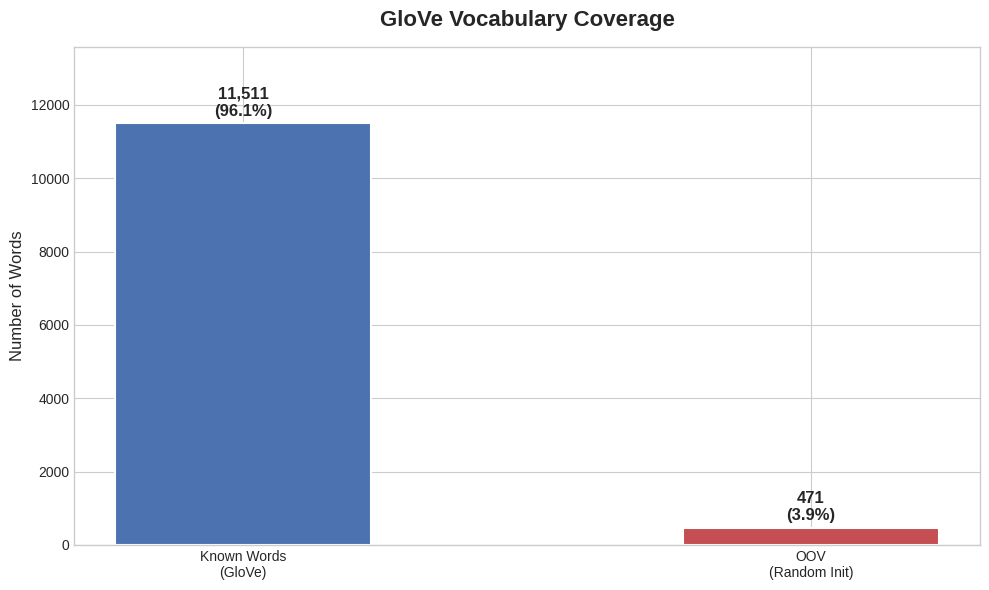

📊 Saved → ../figures/glove_coverage.png


In [38]:
 # ─── Auto-detect environment & set GloVe path ─────────────────────────────────
KAGGLE_GLOVE_PATH = '/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt'
LOCAL_GLOVE_PATH  = '../embeddings/glove.6B.100d.txt'

if os.path.exists(KAGGLE_GLOVE_PATH):
    glove_path = KAGGLE_GLOVE_PATH
    print("✅ Running on Kaggle — GloVe dataset detected.")
elif os.path.exists(LOCAL_GLOVE_PATH):
    glove_path = LOCAL_GLOVE_PATH
    print("✅ Running locally — GloVe file found.")
else:
    glove_path = None
    print("⚠️  GloVe file not found. Using random embedding matrix.")
    print("   → On Kaggle: Add 'glove.6B.100d.txt' dataset via Add Input.")
    print("   → Locally  : Place glove.6B.100d.txt in ../embeddings/")

# ─── Config ───────────────────────────────────────────────────────────────────
embedding_dim = 100
vocab_size    = len(vocab)

# ─── Load GloVe vectors ───────────────────────────────────────────────────────
embeddings_index = {}
found_glove      = False

if glove_path:
    print(f"\nLoading GloVe vectors from:\n  {glove_path}")
    with open(glove_path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word   = values[0]
            coefs  = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    found_glove = True
    print(f"Loaded {len(embeddings_index):,} word vectors.")

# ─── Build embedding matrix ───────────────────────────────────────────────────
embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, embedding_dim))

# PAD → zero vector
if '<PAD>' in vocab:
    embedding_matrix[vocab['<PAD>']] = np.zeros(embedding_dim)

# UNK → mean of all GloVe vectors (or stays random if no GloVe)
if found_glove and embeddings_index:
    glove_mean = np.mean(list(embeddings_index.values()), axis=0)
    if '<UNK>' in vocab:
        embedding_matrix[vocab['<UNK>']] = glove_mean

hits, misses = 0, 0

if found_glove:
    for word, i in vocab.items():
        if word in ('<PAD>', '<UNK>'):
            continue
        embedding_vector = embeddings_index.get(word.lower())
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            misses += 1
else:
    misses = vocab_size

coverage = (hits / vocab_size * 100) if vocab_size > 0 else 0
print(f"\n📊 GloVe Coverage  : {hits:,} / {vocab_size:,} words  ({coverage:.1f}%)")
print(f"   OOV (random)   : {misses:,} words")

# ─── Save embedding matrix ────────────────────────────────────────────────────
os.makedirs('../embeddings', exist_ok=True)
np.save('../embeddings/embedding_matrix.npy', embedding_matrix)
print("\n💾 Saved → ../embeddings/embedding_matrix.npy")

# ─── Plot coverage ────────────────────────────────────────────────────────────
os.makedirs('../figures', exist_ok=True)

plt.figure(figsize=(10, 6))
categories = ['Known Words\n(GloVe)', 'OOV\n(Random Init)']
counts     = [hits, misses]
colors     = ['#4C72B0', '#C44E52']

bars = plt.bar(categories, counts, color=colors, width=0.45, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts):
    pct = count / vocab_size * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.01,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.title('GloVe Vocabulary Coverage', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Number of Words', fontsize=12)
plt.ylim(0, max(counts) * 1.18)
plt.tight_layout()
plt.savefig('../figures/glove_coverage.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Saved → ../figures/glove_coverage.png")

### 🔤 5. Character-Level Encoding

To build character-level embeddings using a CNN, each word must be decomposed into its constituent characters. We represent words as arrays of character IDs.
Here we demonstrate how our vocabulary translates raw strings into sequences of indices.


In [31]:
def encode_chars(word, char_vocab, max_word_len=15):
    # Convert a single word to a list of character indices
    char_ids = [char_vocab.get(c, char_vocab.get('<UNK>', 1)) for c in word]
    # Truncate or Pad
    if len(char_ids) > max_word_len:
        char_ids = char_ids[:max_word_len]
    else:
        char_ids += [char_vocab.get('<PAD>', 0)] * (max_word_len - len(char_ids))
    return char_ids

sample_word = "University"
encoded = encode_chars(sample_word, char_vocab)
print(f"Sample Word: {sample_word}")
print(f"Character IDs: {encoded}")
print(f"Character Vocabulary Size: {len(char_vocab)}")


Sample Word: University
Character IDs: [3, 13, 19, 41, 5, 4, 9, 19, 8, 17, 0, 0, 0, 0, 0]
Character Vocabulary Size: 86


### 🧩 6. PyTorch Dataset & DataLoader

A crucial step for PyTorch models is the `Dataset` and `DataLoader`.
Our NERDataset needs to return:
- **`input_ids`**: The integer word IDs.
- **`char_ids`**: A 2D matrix of character IDs for each word.
- **`labels`**: The NER tag IDs.
- **`attention_mask`**: 1 for real words, 0 for `<PAD>`.

**Why `-100` for ignored labels?**
PyTorch's `CrossEntropyLoss` ignores targets with the value `-100` by default. This is perfect for padding tokens, ensuring they don't contribute to the loss or gradients.


In [33]:
 class NERDataset(Dataset):
    def __init__(self, data, vocab, char_vocab, tag2id, max_len=128, max_word_len=15):
        self.data = data
        self.vocab = vocab
        self.char_vocab = char_vocab
        self.tag2id = tag2id
        self.max_len = max_len
        self.max_word_len = max_word_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokens = item['tokens']
        tags = item['ner_tags']

        # Prepare arrays
        input_ids = []
        char_ids = []
        labels = []
        attention_mask = []

        for i in range(min(len(tokens), self.max_len)):
            word = tokens[i]
            tag = tags[i]
            
            input_ids.append(self.vocab.get(word.lower(), self.vocab.get('<UNK>', 1)))
            char_ids.append(encode_chars(word, self.char_vocab, self.max_word_len))
            labels.append(tag) # Tags are already integers in HuggingFace CoNLL2003
            attention_mask.append(1)

        # Padding
        pad_len = self.max_len - len(input_ids)
        if pad_len > 0:
            input_ids += [self.vocab.get('<PAD>', 0)] * pad_len
            char_ids += [[self.char_vocab.get('<PAD>', 0)] * self.max_word_len] * pad_len
            labels += [-100] * pad_len
            attention_mask += [0] * pad_len

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'char_ids': torch.tensor(char_ids, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long)
        }

# Load dataset using the Kaggle-compatible Parquet mirror
print("Loading CoNLL-2003 dataset snippet...")
raw_datasets = load_dataset("lhoestq/conll2003")

# Dummy tag2id for demonstration (actual should match your vocab definition)
tag2id = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}

train_dataset = NERDataset(raw_datasets['train'], vocab, char_vocab, tag2id, max_len=64)
val_dataset = NERDataset(raw_datasets['validation'], vocab, char_vocab, tag2id, max_len=64)
test_dataset = NERDataset(raw_datasets['test'], vocab, char_vocab, tag2id, max_len=64)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# Print sample batch
sample_batch = next(iter(train_loader))
print("\nSample Batch Shapes:")
print(f"input_ids: {sample_batch['input_ids'].shape}")
print(f"char_ids: {sample_batch['char_ids'].shape}")
print(f"labels: {sample_batch['labels'].shape}")
print(f"attention_mask: {sample_batch['attention_mask'].shape}")

# Ensure working directory exists
os.makedirs('/kaggle/working/data', exist_ok=True)

# Save DataLoaders to explicit Kaggle working path
dataloaders = {
    'train': train_loader,
    'val': val_loader,
    'test': test_loader
}
torch.save(dataloaders, '/kaggle/working/data/dataloaders.pth')
print("✅ Saved dataloaders.pth successfully to /kaggle/working/data/")

Loading CoNLL-2003 dataset snippet...

Sample Batch Shapes:
input_ids: torch.Size([32, 64])
char_ids: torch.Size([32, 64, 15])
labels: torch.Size([32, 64])
attention_mask: torch.Size([32, 64])
✅ Saved dataloaders.pth successfully to /kaggle/working/data/


### 📊 7. Embedding Space Visualization (Bonus)

Word embeddings project words into a high-dimensional space (100D in this case) where semantic relationships are captured by distance and direction. 
To visualize this, we can use dimensionality reduction techniques like **PCA (Principal Component Analysis)** or **t-SNE** to map these vectors into 2D space.


Found 8 words out of 10 in vocabulary.


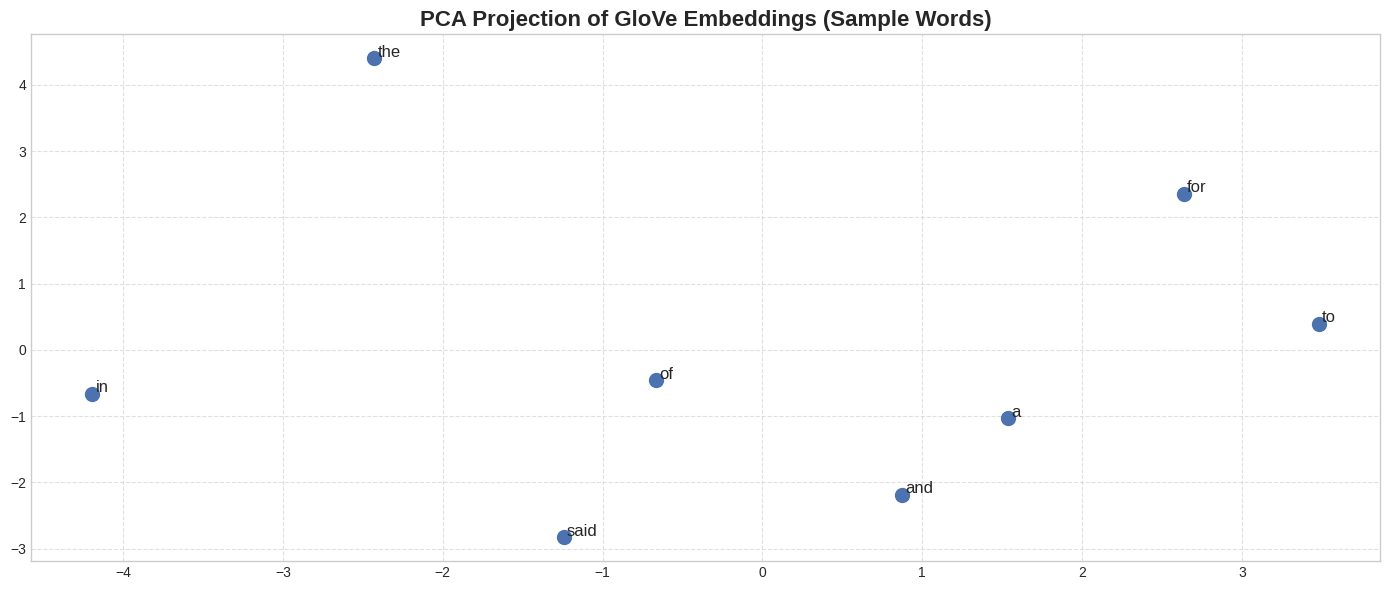

✅ PCA plot generated and saved successfully to /kaggle/working/figures/


In [36]:
# Select common words guaranteed to exist in CoNLL-2003 training vocabulary
sample_words = ['the', 'of', 'in', 'to', 'a', 'and', 'said', 'for', 'london', 'germany']

# Extract their vectors safely
vectors = []
labels = []

for w in sample_words:
    word_key = w.lower() if w.lower() in vocab else w
    if word_key in vocab:
        vectors.append(embedding_matrix[vocab[word_key]])
        labels.append(w)
        
print(f"Found {len(vectors)} words out of {len(sample_words)} in vocabulary.")

if len(vectors) > 2: # Need at least 2 points for PCA
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)
    
    plt.figure(figsize=(14, 6))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='#4C72B0', s=100)
    
    for i, label in enumerate(labels):
        plt.annotate(label, (vectors_2d[i, 0] + 0.02, vectors_2d[i, 1] + 0.02), fontsize=12)
        
    plt.title('PCA Projection of GloVe Embeddings (Sample Words)', fontsize=16, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Ensure figures directory exists in working path
    os.makedirs('/kaggle/working/figures', exist_ok=True)
    plt.savefig('/kaggle/working/figures/glove_pca.png', dpi=300)
    plt.show()
    print("✅ PCA plot generated and saved successfully to /kaggle/working/figures/")
else:
    print("Not enough sample words found in vocab to perform PCA.")

### ✅ 8. Notebook Summary

In this notebook, we completed the data preparation pipeline for deep learning models:
- **Loaded Vocabularies:** Reused the consistent token mappings from Notebook 01.
- **Handled OOV Words:** Discussed how Character-Level CNNs complement word embeddings.
- **GloVe Embeddings:** Built and saved an `embedding_matrix.npy` to initialize our model's embedding layer, with `<UNK>` vector averaging.
- **PyTorch Integration:** Created a highly customized `NERDataset` that outputs token IDs, character grids, masks, and intelligently padded labels (`-100`).
- **DataLoaders Saved:** Finalized datasets are saved as `dataloaders.pth` for immediate use in training notebooks.
- **Visualized Embeddings:** Used PCA to explore the semantic structure of our vector space.

➡️ **Next Up:** `03_Classic_DeepLearning_Models.ipynb` — We will use these exact dataloaders to train BiLSTM and BiLSTM-CRF models!
